[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


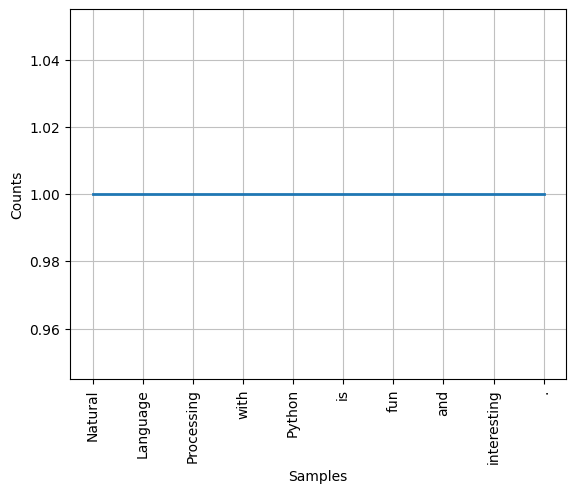

In [3]:
# 1. Perform word tokenization using NLTK and plot a word frequency distribution

import nltk
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
import matplotlib.pyplot as plt
nltk.download('punkt_tab')

nltk.download('punkt')

text = "Natural Language Processing with Python is fun and interesting."
tokens = word_tokenize(text)
freq_dist = FreqDist(tokens)

# Plotting the frequency distribution
freq_dist.plot(30, cumulative=False)
plt.show()


In [4]:
# 2. Use SpaCy for dependency parsing of a sentence

import spacy

nlp = spacy.load("en_core_web_sm")
doc = nlp("Natural Language Processing is interesting.")
for token in doc:
    print(f'{token.text} -> {token.dep_} -> {token.head.text}')


Natural -> compound -> Language
Language -> compound -> Processing
Processing -> nsubj -> is
is -> ROOT -> is
interesting -> acomp -> is
. -> punct -> is


In [2]:
# 3. Use TextBlob for performing text classification based on polarity

from textblob import TextBlob

text = "Natural Language Processing is amazing!"
blob = TextBlob(text)
polarity = blob.sentiment.polarity
print(f'Polarity: {polarity}')


Polarity: 0.42500000000000004


In [5]:
# 4. Extract named entities from a text using SpaCy

import spacy

nlp = spacy.load("en_core_web_sm")
text = "Barack Obama was the 44th President of the United States."
doc = nlp(text)
for ent in doc.ents:
    print(ent.text, ent.label_)


Barack Obama PERSON
44th ORDINAL
the United States GPE


In [6]:
# 5. Calculate TF-IDF scores for a given text using Scikit-learn?

from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "Natural language processing with Python.",
    "Scikit-learn makes machine learning fun!",
    "Text processing and classification."
]

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)
print(tfidf_matrix.toarray())
print(vectorizer.get_feature_names_out())


[[0.         0.         0.         0.46735098 0.         0.
  0.         0.         0.46735098 0.35543247 0.46735098 0.
  0.         0.46735098]
 [0.         0.         0.40824829 0.         0.40824829 0.40824829
  0.40824829 0.40824829 0.         0.         0.         0.40824829
  0.         0.        ]
 [0.52863461 0.52863461 0.         0.         0.         0.
  0.         0.         0.         0.40204024 0.         0.
  0.52863461 0.        ]]
['and' 'classification' 'fun' 'language' 'learn' 'learning' 'machine'
 'makes' 'natural' 'processing' 'python' 'scikit' 'text' 'with']


In [7]:
# 6. Create a custom text classifier using NLTK's Naive Bayes classifier

import nltk
from nltk.corpus import movie_reviews
from nltk.classify import NaiveBayesClassifier
from nltk.classify.util import accuracy as nltk_accuracy
import random

nltk.download('movie_reviews')

# Extract features
def extract_features(words):
    return dict([(word, True) for word in words])

# Load the dataset
documents = [(list(movie_reviews.words(fileid)), category)
              for category in movie_reviews.categories()
              for fileid in movie_reviews.fileids(category)]
random.shuffle(documents)

# Split into training and testing
train_set, test_set = documents[:1600], documents[1600:]
train_features = [(extract_features(doc), category) for (doc, category) in train_set]
test_features = [(extract_features(doc), category) for (doc, category) in test_set]

# Train a Naive Bayes classifier
classifier = NaiveBayesClassifier.train(train_features)

# Evaluate the classifier
accuracy = nltk_accuracy(classifier, test_features)
print(f'Accuracy: {accuracy * 100:.2f}%')
classifier.show_most_informative_features(5)


[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.


Accuracy: 74.00%
Most Informative Features
                   sucks = True              neg : pos    =     16.1 : 1.0
               marvelous = True              pos : neg    =     13.8 : 1.0
                  seagal = True              neg : pos    =     13.5 : 1.0
                riveting = True              pos : neg    =     12.5 : 1.0
               ludicrous = True              neg : pos    =     12.0 : 1.0


In [8]:
# 7. Use a pre-trained model from Hugging Face for text classification

from transformers import pipeline

classifier = pipeline("sentiment-analysis")
result = classifier("Natural Language Processing is amazing!")
print(result)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9998788833618164}]


In [9]:
# 8. Perform text summarization using Hugging Face transformers

from transformers import pipeline

summarizer = pipeline("summarization")
text = """
Natural Language Processing (NLP) is a field of artificial intelligence that focuses on the interaction between
computers and humans through natural language. The ultimate goal of NLP is to enable computers to understand,
interpret, and generate human language in a way that is both meaningful and useful. NLP is used in a variety of
applications, including sentiment analysis, machine translation, and speech recognition.
"""
summary = summarizer(text, max_length=50, min_length=25, do_sample=False)
print(summary)


No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.80k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.22G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

Device set to use cpu


[{'summary_text': ' Natural Language Processing (NLP) is a field of artificial intelligence that focuses on the interaction between computers and humans through natural language . The ultimate goal of NLP is to enable computers to understand, interpret, and generate human language in a'}]


In [ ]:
# 9. Create a simple RNN for text classification using Keras

import numpy as np
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, Embedding
from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences

# Sample data
texts = ["I love natural language processing", "Deep learning is amazing", "Keras makes life easy"]
labels = [1, 1, 0]

# Tokenization
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index

data = pad_sequences(sequences, maxlen=10)

# Build RNN model
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=32, input_length=10))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(data, np.array(labels), epochs=10, batch_size=2)


In [ ]:
# 10. Train a Bidirectional LSTM for text classification

from keras.layers import Bidirectional, LSTM

# Build Bidirectional LSTM model
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=32, input_length=10))
model.add(Bidirectional(LSTM(32)))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(data, np.array(labels), epochs=10, batch_size=2)


In [ ]:
# 11. Implement GRU (Gated Recurrent Unit) for text classification

from keras.layers import GRU

# Build GRU model
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=32, input_length=10))
model.add(GRU(32))
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(data, np.array(labels), epochs=10, batch_size=2)


In [ ]:
# 12. Implement a text generation model using LSTM with Keras

from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

# Sample text data
text = "The quick brown fox jumps over the lazy dog"
text = text.lower()
chars = sorted(list(set(text)))
char_indices = {c: i for i, c in enumerate(chars)}
indices_char = {i: c for i, c in enumerate(chars)}

maxlen = 10
step = 1
sentences = []
next_chars = []

for i in range(0, len(text) - maxlen, step):
    sentences.append(text[i: i + maxlen])
    next_chars.append(text[i + maxlen])

X = np.zeros((len(sentences), maxlen, len(chars)), dtype=np.bool)
y = np.zeros((len(sentences), len(chars)), dtype=np.bool)
for i, sentence in enumerate(sentences):
    for t, char in enumerate(sentence):
        X[i, t, char_indices[char]] = True
    y[i, char_indices[next_chars[i]]] = True

# Build LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(maxlen, len(chars))))
model.add(Dense(len(chars), activation='softmax'))

model.compile(optimizer='rmsprop', loss='categorical_crossentropy')

# Train model
model.fit(X, y, batch_size=128, epochs=10)

# Text generation
def generate_text(seed_text, next_chars=100):
    generated = ''
    sentence = seed_text.lower()
    for _ in range(next_chars):
        x_pred = np.zeros((1, maxlen, len(chars)))
        for t, char in enumerate(sentence):
            x_pred[0, t, char_indices[char]] = 1
        preds = model.predict(x_pred, verbose=0)[0]
        next_index = np.argmax(preds)
        next_char = indices_char[next_index]
        generated += next_char
        sentence = sentence[1:] + next_char
    return generated

print(generate_text("The quick"))


In [ ]:
# 13. Implement a simple Bi-directional GRU for sequence labeling

from keras.layers import Bidirectional, GRU
from keras.preprocessing.sequence import pad_sequences
from keras.utils import to_categorical

# Sample data
texts = ["I love natural language processing", "Deep learning is amazing", "Keras makes life easy"]
labels = [[0, 1, 1, 0, 0], [0, 0, 1, 1], [0, 1, 1, 0]]

# Tokenization
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
word_index = tokenizer.word_index
data = pad_sequences(sequences, maxlen=10)
labels = pad_sequences(labels, maxlen=10)

# Convert labels to categorical
labels = to_categorical(labels, num_classes=2)

# Build Bi-directional GRU model
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=32, input_length=10))
model.add(Bidirectional(GRU(32, return_sequences=True)))
model.add(Dense(2, activation='softmax'))

model.compile(optimizer='rmsprop', loss='categorical_crossentropy', metrics=['accuracy'])
model[_{{{CITATION{{{_1{](https://github.com/wzard/Algora/tree/7f827c94ec778ac189031c2faf02b2b15b966768/datasets%2Fbase.py)[_{{{CITATION{{{_2{](https://github.com/ericrincon/DeepLANBot/tree/435e1213cebb33f3e9bd15e3bf350c301dbc5068/Experiment.py)[_{{{CITATION{{{_3{](https://github.com/hosankang/AI_Class/tree/2fcac1e368b27c13fb4a4278c64ba63770d3d552/chars_rnn.py)